In [2]:
import os
import cv2
import json
import math
import random
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R
import traceback

# ======================= User Config =======================
SYNC_CSV_PATH = "../Meca500/Meca500_matched_joint_angle.csv"
POSE_ARUCO_JSON_PATH = "../Meca500/Meca500_aruco_pose_summary.json"
CALIB_DIR = "../Meca500/Meca500_calib_cam_from_conf"

# 저장 경로
OUT_DIR = "./Meca500_to_DREAM"

# 이미지 왜곡 계수를 투영에 반영할지 여부(원본 이미지에 맞추는 용도)
USE_DISTORTION = True

# ======================= Kinematics =======================
def get_dh_matrix(a, d, alpha, theta):
    """표준 DH 파라미터를 사용하여 변환 행렬을 계산합니다. (각도는 degree 단위로 입력)"""
    alpha_rad = math.radians(alpha)
    theta_rad = math.radians(theta)
    return np.array([
        [np.cos(theta_rad), -np.sin(theta_rad) * np.cos(alpha_rad),  np.sin(theta_rad) * np.sin(alpha_rad), a * np.cos(theta_rad)],
        [np.sin(theta_rad),  np.cos(theta_rad) * np.cos(alpha_rad), -np.cos(theta_rad) * np.sin(alpha_rad), a * np.sin(theta_rad)],
        [0, np.sin(alpha_rad), np.cos(alpha_rad), d],
        [0, 0, 0, 1]
    ])

def angle_to_joint_coordinate(joint_angles):
    """주어진 관절 각도에 대한 모든 조인트의 3D 좌표를 계산합니다."""
    dh_params = [
        {'alpha': -90, 'a': 0,     'd': 0.135, 'theta_offset': 0},
        {'alpha': 0,   'a': 0.135, 'd': 0,     'theta_offset': -90},
        {'alpha': -90, 'a': 0.038, 'd': 0,     'theta_offset': 0},
        {'alpha': 90,  'a': 0,     'd': 0.120, 'theta_offset': 0},
        {'alpha': -90, 'a': 0,     'd': 0,     'theta_offset': 0},
        {'alpha': 0,   'a': 0,     'd': 0.070, 'theta_offset': 0}
    ]
    joint_coords_3d = [np.array([0, 0, 0])] # J0 (베이스)
    T_cumulative = np.eye(4)
    base_point = np.array([[0], [0], [0], [1]])
    for i in range(6):
        params = dh_params[i]
        theta = joint_angles[i] + params['theta_offset']
        T_i = get_dh_matrix(params['a'], params['d'], params['alpha'], theta)
        T_cumulative = T_cumulative @ T_i
        joint_pos = T_cumulative @ base_point
        joint_coords_3d.append(joint_pos[:3, 0])
    return np.array(joint_coords_3d, dtype=np.float32)

def project_to_pixel(coords_3d, rvec, tvec, camera_matrix, dist_coeffs):
    """3D 좌표를 2D 이미지 평면에 투영합니다."""
    pixel_coords, _ = cv2.projectPoints(coords_3d, rvec, tvec, camera_matrix, dist_coeffs)
    return pixel_coords.reshape(-1, 2)

# ======================= Dataset Builder =======================
def build_sample_for_row(row, aruco_result, calib_data, view_name, cam_name):
    # 1) 6축 관절 값 추출
    joint_angles = [float(row[f'joint_{j}']) for j in range(1, 7)]

    # 2) 순방향 기구학(FK) 계산: 6 DoF 관절 값을 사용
    joint_world = angle_to_joint_coordinate(joint_angles)  # (N,3) WORLD/BASE

    # --- 수정된 부분: 오일러 각도(degree)를 회전 벡터(radian)로 변환 ---
    # Scipy 라이브러리를 사용하여 변환. 'xyz' 순서는 데이터 생성 방식에 따라 변경될 수 있습니다.
    euler_angles_deg = [
        aruco_result['rvec_x'],
        aruco_result['rvec_y'],
        aruco_result['rvec_z']
    ]
    rvec = np.deg2rad(euler_angles_deg).reshape(3, 1)

    tvec = np.array([
        aruco_result['tvec_x'],
        aruco_result['tvec_y'],
        aruco_result['tvec_z']
    ], dtype=np.float64).reshape(3, 1)
    
    # 3) 픽셀 투영 (OpenCV: WORLD->CAM extrinsic 사용)
    K = np.array(calib_data["camera_matrix"], dtype=np.float64)
    dist = np.array(calib_data["_comment"], dtype=np.float64) if USE_DISTORTION else np.zeros((5, 1))

    pixel_coords = project_to_pixel(joint_world, rvec, tvec, K, dist)

    # 4) 카메라 프레임 3D 좌표도 생성 (location, keypoints.location 용)
    R_cam_world, _ = cv2.Rodrigues(rvec)
    Xw = joint_world.astype(np.float64)                      # (N,3)
    joint_cam = (R_cam_world @ Xw.T).T + tvec.ravel()       # (N,3)

    # 5) 기준점(location) = link0(J0) in CAMERA
    base_cam = joint_cam[0].astype(float).tolist()

    # 6) keypoints (이름-좌표 매핑)
    LINK_NAMES = [
        "Meca500_link0", "Meca500_link1", "Meca500_link2", "Meca500_link3",
        "Meca500_link4", "Meca500_link5", "Meca500_link6"
    ]
    n = min(len(LINK_NAMES), joint_cam.shape[0])
    keypoints = []
    for i in range(n):
        keypoints.append({
            "name": LINK_NAMES[i],
            "location": [float(joint_cam[i, 0]), float(joint_cam[i, 1]), float(joint_cam[i, 2])],
            "projected_location": [float(pixel_coords[i, 0]), float(pixel_coords[i, 1])]
        })

    # 7) joints 기록
    JOINT_NAMES = [
        "Meca500_joint1", "Meca500_joint2", "Meca500_joint3", "Meca500_joint4",
        "Meca500_joint5", "Meca500_joint6"
    ]

    joints_out = [
        {"name": n, "position": float(np.radians(v)), "velocity": 0.0}
        for n, v in zip(JOINT_NAMES, joint_angles)
    ]


    # 8) 샘플 조립
    sample = {
        "objects": [{
            "class": "Meca500",
            "visibility": 1,
            "location": base_cam,
            "keypoints": keypoints
        }],
        "sim_state": {"joints": joints_out},
        "meta": {
            "image_path": row["image_path"],
            "view": view_name,
            "cam": cam_name,
            "K": K.tolist(),
            "dist_coeffs": dist.tolist(),
            "aruco_rvec_tvec": {
                # meta 정보에는 변환된 radian 값 저장
                "rvec": [float(rvec[0,0]), float(rvec[1,0]), float(rvec[2,0])],
                "tvec": [float(tvec[0,0]), float(tvec[1,0]), float(tvec[2,0])]
            }
        }
    }
    return sample

# ======================= Main =======================
def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    # 1) 데이터 로드
    try:
        df_sync = pd.read_csv(SYNC_CSV_PATH)
        with open(POSE_ARUCO_JSON_PATH, 'r') as f:
            pose_aruco_results = json.load(f)
    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        return

    # --- 수정된 부분: Meca500은 ArUco 포즈가 1개이므로, 리스트의 첫 번째 요소를 사용 ---
    if not pose_aruco_results:
        print("❌ ArUco pose data is empty!")
        return
    aruco_result = pose_aruco_results[0]
    cam_name = aruco_result.get("cam", "unknown_cam")
    view_name = aruco_result.get("view", "unknown_view")
    
    # calib 파일 로드 (루프 밖에서 한 번만 로드)
    calib_path = os.path.join(CALIB_DIR, f"Meca500_calib.json")
    if not os.path.exists(calib_path):
        print(f"⚠️ Calib file not found: {calib_path}. Exiting.")
        return
    with open(calib_path, 'r') as f:
        calib_data = json.load(f)

    # 3) 전체 행을 순회하며 샘플 생성
    total = len(df_sync)
    saved = 0
    skipped = 0

    for idx, row in df_sync.iterrows():
        try:
            image_path = row['image_path']
            img_name = os.path.basename(image_path)
            
            # 샘플 생성
            sample = build_sample_for_row(
                row=row,
                aruco_result=aruco_result, # 추출해둔 단일 aruco 결과 사용
                calib_data=calib_data,
                cam_name=cam_name,
                view_name=view_name
            )

            # 개별 JSON 저장
            img_stem = os.path.splitext(img_name)[0]
            out_json = os.path.join(OUT_DIR, f"{img_stem}.json")
            with open(out_json, "w", encoding="utf-8") as f:
                json.dump(sample, f, ensure_ascii=False, indent=2)

            saved += 1
            if saved % 100 == 0:
                print(f"✅ Saved {saved} / {total} (progress)")

        except Exception as e:
            print(f"\n❌ [{idx}] Unexpected error for {row.get('image_path', 'unknown')}: {type(e).__name__}: {e}")
            traceback.print_exc()
            skipped += 1
            continue

    print(f"\n=== Done ===\nTotal rows: {total}\nSaved: {saved}\nSkipped: {skipped}\nOutput dir: {OUT_DIR}")

if __name__ == "__main__":
    main()


✅ Saved 100 / 998 (progress)
✅ Saved 200 / 998 (progress)
✅ Saved 300 / 998 (progress)
✅ Saved 400 / 998 (progress)
✅ Saved 500 / 998 (progress)
✅ Saved 600 / 998 (progress)
✅ Saved 700 / 998 (progress)
✅ Saved 800 / 998 (progress)
✅ Saved 900 / 998 (progress)

=== Done ===
Total rows: 998
Saved: 998
Skipped: 0
Output dir: ./Meca500_to_DREAM


../../dataset/Meca500/image/image6.jpg
[Reprojection] mean L2 error: 0.000px
  Meca500_link0: 0.000px
  Meca500_link1: 0.000px
  Meca500_link2: 0.000px
  Meca500_link3: 0.000px
  Meca500_link4: 0.000px
  Meca500_link5: 0.000px
  Meca500_link6: 0.000px


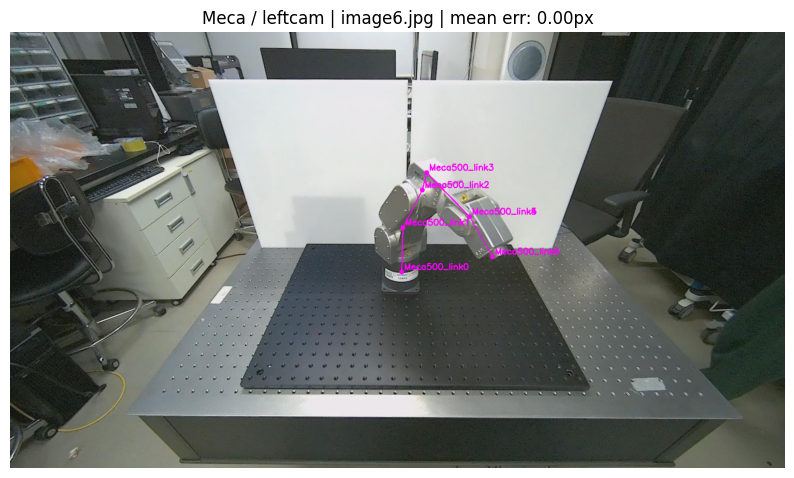

In [3]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_sample(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        sample = json.load(f)
    obj = sample["objects"][0]
    meta = sample["meta"]
    return obj, meta

def project_camframe_points(pts_cam, K, dist):
    """카메라 프레임 3D -> 픽셀 (extrinsic = I)"""
    rvec = np.zeros((3,1), np.float64)
    tvec = np.zeros((3,1), np.float64)
    pts = np.asarray(pts_cam, dtype=np.float64).reshape(-1,1,3)
    K = np.asarray(K, dtype=np.float64)
    dist = np.asarray(dist, dtype=np.float64)
    img_pts, _ = cv2.projectPoints(pts, rvec, tvec, K, dist)
    return img_pts.reshape(-1,2)

def visualize_json(json_path, show_ids=True, compute_reproj_error=True, point_radius=6, thickness=2):
    obj, meta = load_sample(json_path)
    image_path = os.path.join("../", meta["image_path"])
    print(image_path)
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # 이미지 로드 (왜곡 보정하지 않음: projected_location이 왜곡 좌표라고 가정)
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 키포인트(픽셀) 수집
    names = []
    uv_from_json = []
    cam3d = []
    for kp in obj["keypoints"]:
        names.append(kp["name"])
        uv_from_json.append(kp["projected_location"])
        cam3d.append(kp["location"])
    uv_from_json = np.asarray(uv_from_json, dtype=np.float64)
    cam3d = np.asarray(cam3d, dtype=np.float64)

    # 재투영 (옵션)
    reproj_errs = None
    if compute_reproj_error and cam3d.size > 0:
        K = meta["K"]
        dist = meta["dist_coeffs"]
        uv_reproj = project_camframe_points(cam3d, K, dist)
        reproj_errs = np.linalg.norm(uv_reproj - uv_from_json, axis=1)
        mean_err = float(reproj_errs.mean())
        print(f"[Reprojection] mean L2 error: {mean_err:.3f}px")
        for n, e in zip(names, reproj_errs):
            print(f"  {n:>12s}: {e:.3f}px")

    # 드로잉
    overlay = img_rgb.copy()
    color = (255, 0, 255)  # magenta
    for i, (u, v) in enumerate(uv_from_json.astype(int)):
        cv2.circle(overlay, (u, v), point_radius, color, -1)
        if show_ids:
            label = f"{names[i]}"
            cv2.putText(overlay, label, (u + 6, v - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, thickness)

        if i > 0:
            u_prev, v_prev = uv_from_json[i-1].astype(int)
            cv2.line(overlay, (u_prev, v_prev), (u, v), color, thickness)

    title = f"{meta.get('view','?')} / {meta.get('cam','?')} | {os.path.basename(image_path)}"
    if reproj_errs is not None:
        title += f" | mean err: {reproj_errs.mean():.2f}px"

    plt.figure(figsize=(10, 8))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(title)
    plt.show()

if __name__ == "__main__":
    # 예시: 하나의 JSON 파일 경로를 넣어 실행
    json_path = "/home/najo/NAS/DIP/2025_ICRA_Multi_View_Robot_Pose_Estimation/dataset/Converted_dataset/Meca500_to_DREAM/image6.json"  # <- 여기를 교체
    visualize_json(json_path)
